# Deep Learning on MNIST

In [168]:
# Define a variable to store the training/test image/ label names of the MNIST dataset in a dictionary

data_sources = {
    "training_images": "train-images-idx3-ubyte.gz", #60 000 training images
    "test_images": "t10k-images-idx3-ubyte.gz", # 10 000 test images
    "training_labels": "train-labels-idx1-ubyte.gz",   # 60 000 training labels
    "test_labels": "t10k-labels-idx1-ubyte.gz" # 10 000 test labels


}


In [169]:
# Load data

import os

data_dir = os.path.expanduser("~/Documents/MNIST_Dataset")

In [170]:
# Decompress the 4 files and create 4 narrays, saving them into a dictionary. 
# Each original image is of size 28 x 28 
# therefore we reshape the images by multiplying 28 by 28 (784)


import gzip
import numpy as np

mnist_dataset = {}

# Images
for key in ("training_images", "test_images"):
    with gzip.open(os.path.join(data_dir, data_sources[key]), "rb") as mnist_file:
        mnist_dataset[key] = np.frombuffer(mnist_file.read(), np.uint8, offset=16).reshape(-1, 28 * 28)


# Labels
for key in ("training_labels", "test_labels"):
    with gzip.open(os.path.join(data_dir, data_sources[key]), "rb") as mnist_file:
        mnist_dataset[key] = np.frombuffer(mnist_file.read(), np.uint8, offset=8)

In [171]:
# Split the data into training and test sets using the standard notation of x for data and y for labels, 
# calling the training and test set images x_train and x_test, 
# and labels y_train and y_test


x_train, y_train, x_test, y_test = (mnist_dataset["training_images"],
                                    mnist_dataset["training_labels"],
                                    mnist_dataset["test_images"],
                                    mnist_dataset["test_labels"],
                                    )



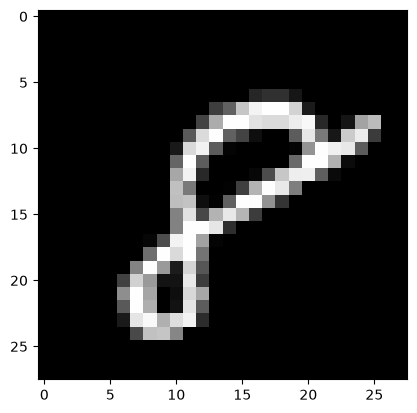

In [172]:
# Inspect some images using matplotlib

import matplotlib.pyplot as plt

# Take the 60000th image (indexed at 59 999) from the training set,
# reshape from (784,) to (28, 28) to have a valid shape for displaying purposes.

mnist_image = x_train[59999, :].reshape(28, 28)

fig, ax = plt.subplots()
# Set the color mapping to grayscale to have a black background
ax.imshow(mnist_image, cmap="gray")

np.uint8(8)

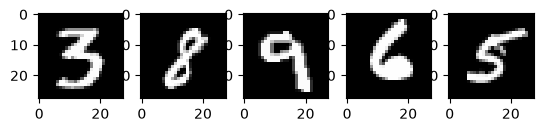

In [173]:
# Display 5 random images from the training set

num_examples = 5
seed = 147197952744
rng = np.random.default_rng(seed)


fig, axes = plt.subplots(1, num_examples)
for sample, ax in zip(rng.choice(x_train, size=num_examples, replace=False), axes):
    ax.imshow(sample.reshape(28, 28), cmap="gray")


# Display the label of the 60000th image (indexed at 59 999) from the training set.
y_train[59999]


### Preprocess the data

In [174]:
# Normalize the arrays by diving them by 255 (thus promoting the data type from uint8 to float64)
# and then assign the train and test image data variables -- x_train and x_test to training_images and training_labels respectively
# To reduce model training and evaluation in this example, only a subset of the training and test images will be used.
# Only 1000 samples each out of the complete datasets

training_sample, test_sample = 1000, 1000
training_images = x_train[0:training_sample] / 255
test_images = x_test[0:test_sample] / 255

In [175]:
# Define a function that performs one-hot encoding on arrays

def one_hot_encoding(labels, dimension=10):
    # Define a one-hot variable for an all-zero vector with 10 dimensions (number labels from 0 to 9).
    one_hot_labels = labels[..., None] == np.arange(dimension)[None]
    # Return one-hot encoded labels
    return one_hot_labels.astype(np.float64)

In [176]:
# Encode the labels and assign the values to new variables

training_labels = one_hot_encoding(y_train[:training_sample])
test_labels = one_hot_encoding(y_test[:test_sample])


In [177]:
# Examine a few encoded labels

print(training_labels[0])
print(training_labels[1])
print(training_labels[2])



print()
print("Compare with the originals")
print()
# compare to the originals

print(y_train[0])
print(y_train[1])
print(y_train[2])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]

Compare with the originals

5
0
4


### Build the model and begin with training and testing

In [178]:
# We start by creating a new random number generator, providing a seed for reproducibility

seed = 884736743
rng = np.random.default_rng(seed)

In [179]:
# For the hidden layer, define the ReLU activation function for forward propagation and ReLU's derivative that will be used for during backpropagation


# Define ReLU that returns the input if it's positive and 0 othervise

def relu(x):
    return (x >=0) * x


# Set up a derivative of the ReLU function that returns 1 for a positive input and 0 otherwise.

def relu2deriv(output):
    return output >= 0

In [180]:
# Set values of hyperparameters.


learning_rate = 0.005
epochs = 20
hidden_size = 100
pixels_per_image = 784
num_labels = 10

In [181]:
# Initialize the weight vectors that will be used in the hidden and otput layers with random values.

weights_1 = 0.2 * rng.random((pixels_per_image, hidden_size)) - 0.1
weights_2 = 0.2 * rng.random((hidden_size, num_labels)) - 0.1

In [182]:
# Set up the neural network's learning experiment with a training loop and start the training process. 


# To store training and test set losses and accurate predictions for visualization.
store_training_loss = []
store_training_accurate_pred = []
store_test_loss = []
store_test_accurate_pred = []


# Run the learning experiment for a defined number of epochs (iterations).

for j in range(epochs):
    # Training step #

    # Set the initial loss/error and the number of accurate predictions to zero.
    training_loss = 0.0
    training_accurate_predictions = 0


    # For all the images in the training set, perform a forward pass and backpropagation and adjust weights accordingly.
    for i in range(len(training_images)):

        # Forward propagation/forward pass:

        # 1. The input layer:
        # Initialize the training image data as inputs.
        layer_0 = training_images[i]

        # 2. The hidden layer:
        # Take in the training image data into the middle layer by matrix-multiplying it by randomly initialized weights.
        layer_1 = np.dot(layer_0, weights_1)

        # 3. Pass the hidden layer's output through the ReLU activation function.
        layer_1 = relu(layer_1)

        # 4. Define the dropout function for regularization.
        dropout_mask = rng.integers(low=0, high=2, size=layer_1.shape)

        # 5. Apply dropout to the hidden layer's output.
        layer_1 *= dropout_mask * 2

        # 6. The output layer:
        # Ingest the output of the middle layer into the final layer by matrix-multiplying it by randomly initialized weights.
        # Produce a 10-dimension vector with 10 scores.
        layer_2 = np.dot(layer_1, weights_2)

        # Backpropagation/ backward pass:

        # 1. Measure the training error (loss function) between the actual images labels (the truth) and prediction by the model.
        training_loss += np.sum((training_labels[i] - layer_2)**2)

        # 2. Increment the accurate prediction count.
        training_accurate_predictions += int(np.argmax(layer_2) == np.argmax(training_labels[i]))

        # 3. Differentiate the loss function/error.
        layer_2_delta = training_labels[i] - layer_2

        # 4. Propagate the gradients of the loss functionback through the hidden layer
        layer_1_delta = np.dot(weights_2, layer_2_delta) * relu2deriv(layer_1)

        # 5. Apply the dropout to the gradients.
        layer_1_delta *= dropout_mask

        # 6. Update the weights for the middle and input layers by multiplying them by the learning rate and the gradients.
        weights_1 += learning_rate * np.outer(layer_0, layer_1_delta)
        weights_2 += learning_rate * np.outer(layer_1, layer_2_delta)

    # Store training set losses and accurate predictions.
    store_training_loss.append(training_loss)
    store_training_accurate_pred.append(training_accurate_predictions)

    

    # Evaluate model performance on the test set at each epoch.


    results = relu(test_images @ weights_1) @ weights_2

    # Measure the error between the actual label (truth) and predictions values. 
    test_loss = np.sum((test_labels - results) ** 2)

    # Measure prediction accuracy on test set
    test_loss = np.sum((test_labels - results) ** 2)

    # Measure prediction accuracy on test set
    test_accurate_predictions = np.sum(np.argmax(results, axis=1) == np.argmax(test_labels, axis = 1))

    # Store test set losses and accurate predictions.
    store_test_loss.append(test_loss)
    store_test_accurate_pred.append(test_accurate_predictions)

    # Summarize error and accuracy metrics at each epoch
    print(
        (
            f" Epoch: {j}\n"
            f" Training set error: {training_loss / len(training_images):.3f}\n"
            f" Training set accuracy: {training_accurate_predictions / len(training_images)}\n"
            f" Test set error: {test_loss / len(test_images):.3f}\n"
            f" Test set accuracy: {test_accurate_predictions / len(test_images)}"
        )
    )
    
    
    
    final_accuracy = store_test_accurate_pred[-1] / len(test_images)
    print (f"Final test accuracy: {final_accuracy:.2%}")

 Epoch: 0
 Training set error: 0.898
 Training set accuracy: 0.397
 Test set error: 0.680
 Test set accuracy: 0.582
Final test accuracy: 58.20%
 Epoch: 1
 Training set error: 0.656
 Training set accuracy: 0.633
 Test set error: 0.607
 Test set accuracy: 0.641
Final test accuracy: 64.10%
 Epoch: 2
 Training set error: 0.592
 Training set accuracy: 0.68
 Test set error: 0.569
 Test set accuracy: 0.679
Final test accuracy: 67.90%
 Epoch: 3
 Training set error: 0.556
 Training set accuracy: 0.7
 Test set error: 0.541
 Test set accuracy: 0.708
Final test accuracy: 70.80%
 Epoch: 4
 Training set error: 0.534
 Training set accuracy: 0.732
 Test set error: 0.526
 Test set accuracy: 0.729
Final test accuracy: 72.90%
 Epoch: 5
 Training set error: 0.515
 Training set accuracy: 0.715
 Test set error: 0.500
 Test set accuracy: 0.739
Final test accuracy: 73.90%
 Epoch: 6
 Training set error: 0.495
 Training set accuracy: 0.748
 Test set error: 0.487
 Test set accuracy: 0.753
Final test accuracy: 75

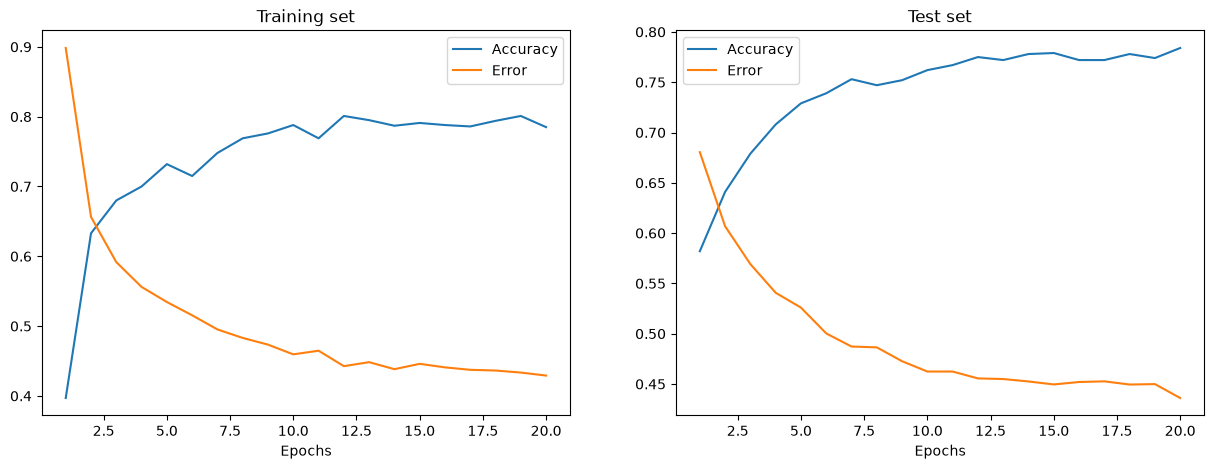

In [183]:
# We can visualize the training and test set errors and accuracy for an instance of this training process

epoch_range = np.arange(epochs) + 1  # Starting from 1


# The training set metrics.
training_metrics = {
    "accuracy": np.asarray(store_training_accurate_pred) / len(training_images),
    "error": np.asarray(store_training_loss) / len(test_images),
}

# The test set metrics
test_metrics = {
    "accuracy": np.asarray(store_test_accurate_pred) / len(test_images),
    "error": np.asarray(store_test_loss) / len(test_images),
}

# Display the plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
for ax, metrics, title in zip(axes, (training_metrics, test_metrics), ("Training set", "Test set")):
    
    # Plot the metrics
    for metric, values in metrics.items():
        ax.plot(epoch_range, values, label=metric.capitalize())
    ax.set_title(title)
    ax.set_xlabel("Epochs")
    ax.legend()


### Optimize the model

In [184]:
learning_rate = 0.005
epochs = 20 #40
hidden_size = 100 #200
pixels_per_image = 784
num_labels = 10

In [185]:
# For the hidden layer, define the ReLU activation function for forward propagation and ReLU's derivative that will be used for during backpropagation


# Define ReLU that returns the input if it's positive and 0 othervise

def relu(x):
    return (x >=0) * x


# Set up a derivative of the ReLU function that returns 1 for a positive input and 0 otherwise.

def relu2deriv(output):
    return output >= 0

In [186]:
# Define softmax function for the output layer

def softmax(x):
    exp_x = np.exp(x - np.max(x))  # Subtract max for numerical stability
    return exp_x / np.sum(exp_x)

In [187]:
# def cross_entropy_loss(predicted, true):
#     # Clip predictions to avoid log(0) which would give -infinity
#     predicted = np.clip(predicted, 1e-12, 1.0)
#     return -np.sum(true * np.log(predicted))

In [188]:
# Initialize the weight vectors that will be used in the hidden and otput layers with random values.

weights_1 = 0.2 * rng.random((pixels_per_image, hidden_size)) - 0.1
weights_2 = 0.2 * rng.random((hidden_size, num_labels)) - 0.1

In [189]:
# To store training and test set losses and accurate predictions for visualization.
store_training_loss = []
store_training_accurate_pred = []
store_test_loss = []
store_test_accurate_pred = []


# Run the learning experiment for a defined number of epochs (iterations).

for j in range(epochs):
    # Training step #

    # Set the initial loss/error and the number of accurate predictions to zero.
    training_loss = 0.0
    training_accurate_predictions = 0


    # For all the images in the training set, perform a forward pass and backpropagation and adjust weights accordingly.


    for i in range(len(training_images)):

        # Forward propagation/forward pass:

        # 1. The input layer:
        # Initialize the training image data as inputs.
        layer_0 = training_images[i]

        # 2. The hidden layer:
        # Take in the training image data into the middle layer by matrix-multiplying it by randomly initialized weights.
        layer_1 = np.dot(layer_0, weights_1)

        # 3. Pass the hidden layer's output through the ReLU activation function.
        layer_1 = relu(layer_1)

        # 4. Define the dropout function for regularization.
        #dropout_mask = rng.integers(low=0, high=2, size=layer_1.shape)

        # 5. Apply dropout to the hidden layer's output.
        #layer_1 *= dropout_mask * 2

        # Temporarily disable dropout while testing Softmax + Cross-Entropy.
        dropout_mask = np.ones(layer_1.shape)

        # No dropout is applied.
        layer_1 *= dropout_mask

        # 6. The output layer:
        # Ingest the output of the middle layer into the final layer by matrix-multiplying it by randomly initialized weights.
        # Produce a 10-dimension vector with 10 scores.
        ##layer_2 = np.dot(layer_1, weights_2)
        layer_2_raw = np.dot(layer_1, weights_2)
        layer_2 = softmax(layer_2_raw)



        # Backpropagation/ backward pass:

        # 1. Measure the training error (loss function) between the actual images labels (the truth) and prediction by the model.
        #training_loss += np.sum((training_labels[i] - layer_2)**2)

        # cross entropy loss
        #training_loss += cross_entropy_loss(layer_2, training_labels[i])
        training_loss += -np.sum(training_labels[i] * np.log(layer_2 + 1e-8))

        # 2. Increment the accurate prediction count.
        training_accurate_predictions += int(np.argmax(layer_2) == np.argmax(training_labels[i]))

        # 3. Differentiate the loss function/error.
        layer_2_delta = training_labels[i] - layer_2
        #layer_2_delta = layer_2 - training_labels[i]
        

        # 4. Propagate the gradients of the loss functionback through the hidden layer
        layer_1_delta = np.dot(weights_2, layer_2_delta) * relu2deriv(layer_1)

        # 5. Apply the dropout to the gradients.
        layer_1_delta *= dropout_mask

        # 6. Update the weights for the middle and input layers by multiplying them by the learning rate and the gradients.
        weights_1 += learning_rate * np.outer(layer_0, layer_1_delta)
        weights_2 += learning_rate * np.outer(layer_1, layer_2_delta)



    # Store training set losses and accurate predictions.
    store_training_loss.append(training_loss)
    store_training_accurate_pred.append(training_accurate_predictions)

    # Evaluation step

    # Evaluate model performance on the test set at each epoch.

    # Unlike the training step, the weights are not modified for each image (or batch). 
    # Therefore the model can be applied to the test images in a vectorized manner, eliminating the need to loop over each image individually:
     

    # Calculate the hidden layer.
    test_layer_1 = relu(test_images @ weights_1)

    # Calculate the raw output scores.
    test_layer_2_raw = test_layer_1 @ weights_2

    #results = relu(test_images @ weights_1) @ weights_2

    # Convert raw scores into probabilities.
    #results = np.apply_along_axis(softmax, 1, relu(test_images @ weights_1) @ weights_2)
    results = np.apply_along_axis(softmax, 1, test_layer_2_raw)

    # Measure the error between the actual label (truth) and predictions values. 
    #test_loss = np.sum((test_labels - results) ** 2)
    #test_loss = -np.sum(test_labels * np.log(np.clip(results, 1e-12, 1.0)))

    # Calculate test cross-entropy loss.
    test_loss = -np.sum(test_labels * np.log(results + 1e-8))


    # Measure prediction accuracy on test set
    test_accurate_predictions = np.sum(np.argmax(results, axis=1) == np.argmax(test_labels, axis = 1))

    # Store test set losses and accurate predictions.
    store_test_loss.append(test_loss)
    store_test_accurate_pred.append(test_accurate_predictions)

    # Summarize error and accuracy metrics at each epoch
    print(
        (
         f" Epoch: {j}\n"
         f" Training set error: {training_loss / len(training_images):.3f}\n"
         f" Training set accuracy: {training_accurate_predictions / len(training_images)}\n"
         f" Test set error: {test_loss / len(test_images):.3f}\n"
         f" Test set accuracy: {test_accurate_predictions / len(test_images)}"
        )
    )

test_accuracy = store_test_accurate_pred [-1] / len(test_images)
print(f"Final test accuracy: {test_accuracy:.2%}")

 Epoch: 0
 Training set error: 1.668
 Training set accuracy: 0.565
 Test set error: 1.181
 Test set accuracy: 0.683
 Epoch: 1
 Training set error: 0.791
 Training set accuracy: 0.804
 Test set error: 0.777
 Test set accuracy: 0.764
 Epoch: 2
 Training set error: 0.537
 Training set accuracy: 0.855
 Test set error: 0.647
 Test set accuracy: 0.796
 Epoch: 3
 Training set error: 0.428
 Training set accuracy: 0.888
 Test set error: 0.583
 Test set accuracy: 0.808
 Epoch: 4
 Training set error: 0.363
 Training set accuracy: 0.897
 Test set error: 0.546
 Test set accuracy: 0.823
 Epoch: 5
 Training set error: 0.317
 Training set accuracy: 0.918
 Test set error: 0.523
 Test set accuracy: 0.834
 Epoch: 6
 Training set error: 0.281
 Training set accuracy: 0.925
 Test set error: 0.507
 Test set accuracy: 0.839
 Epoch: 7
 Training set error: 0.252
 Training set accuracy: 0.935
 Test set error: 0.497
 Test set accuracy: 0.841
 Epoch: 8
 Training set error: 0.227
 Training set accuracy: 0.944
 Test

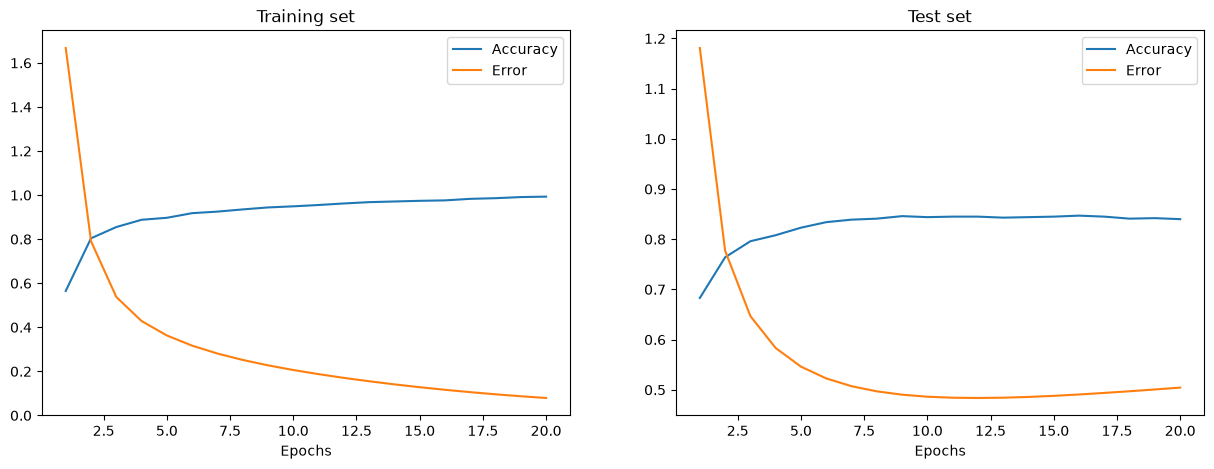

In [190]:
# Visualize the training and test set errors and accuracy for an instance of this training process

epoch_range = np.arange(epochs) + 1  # Starting from 1


# The training set metrics.
training_metrics = {
    "accuracy": np.asarray(store_training_accurate_pred) / len(training_images),
    "error": np.asarray(store_training_loss) / len(test_images),
}

# The test set metrics
test_metrics = {
    "accuracy": np.asarray(store_test_accurate_pred) / len(test_images),
    "error": np.asarray(store_test_loss) / len(test_images),
}

# Display the plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
for ax, metrics, title in zip(axes, (training_metrics, test_metrics), ("Training set", "Test set")):
    # Plot the metrics
    for metric, values in metrics.items():
        ax.plot(epoch_range, values, label=metric.capitalize())
    ax.set_title(title)
    ax.set_xlabel("Epochs")
    ax.legend()
